# Import des librairies

In [10]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np


from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from collections import Counter
from tqdm import tqdm


#import locaux

from import_dataset import load_dataset
from explore_data import downsample_data, plot_xy_grid, plot_3d, txt_to_df, plot_xy_grid_corrige
from Edit_distance import edit_distance

ImportError: cannot import name 'plot_xy_grid_corrige' from 'explore_data' (c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\explore_data.py)

# Chargement des Datasets

In [4]:
#BASE_DIR = os.path.dirname(os.path.abspath(__file__)) le __file__ fait planter le code dans un script python, mais dans un notebook il n'est pas défini, du coup on utilise os.getcwd() pour prendre le répertoire courant du notebook
BASE_DIR = os.getcwd()

DATA_DIR_DOMAIN1 = os.path.join(BASE_DIR, "Dataset", "Domain1_csv")
DATA_DIR_DOMAIN4 = os.path.join(BASE_DIR,"Dataset", "Domain4_csv")

#print(len(os.listdir(DATA_DIR))) validation que tous les chiffiers ont été chargés

def load_domain4_dataset(folder_path):
    """
    Charge le Domain 4 même s'il est au format .txt.

    Les fichiers Domain 4 ont ce format :
    Domain id = 4
    Class id = ...
    User id = ...

    <x>,<y>,<z>,<t>
    ...
    """

    all_data = []
    repetition_counter = {}

    files = sorted(os.listdir(folder_path))

    for filename in files:
        if not filename.endswith(".txt"):
            continue

        file_path = os.path.join(folder_path, filename)

        with open(file_path, "r") as f:
            lines = f.readlines()

        domain_id = int(lines[0].split("=")[1].strip())
        class_id = int(lines[1].split("=")[1].strip())
        user_id = int(lines[2].split("=")[1].strip())

        key = (user_id, class_id)

        if key not in repetition_counter:
            repetition_counter[key] = 1
        else:
            repetition_counter[key] += 1

        repetition = repetition_counter[key]

        df = pd.read_csv(file_path, skiprows=4)

        df.columns = (
            df.columns
            .str.replace("<", "", regex=False)
            .str.replace(">", "", regex=False)
        )

        df["domain_id"] = domain_id
        df["subject_id"] = user_id
        df["digit"] = class_id
        df["repetition"] = repetition
        df["filename"] = filename

        df = df[["subject_id", "digit", "repetition", "x", "y", "z", "t", "domain_id", "filename"]]

        all_data.append(df)

    return all_data


print("Chargement du dataset de Domain1...")
dataset_domain1 = pd.concat(load_dataset(DATA_DIR_DOMAIN1), ignore_index=True) 

print(f"{len(dataset_domain1)} fichiers chargés .") 
print(f"Dimension du dataset : {dataset_domain1.shape}")
print(dataset_domain1.head())

print("\nChargement du dataset de Domain4...")

# Si le dossier Domain 4 contient des .txt, on utilise le chargeur spécial.
# Sinon, on garde ton load_dataset classique.
domain4_files = os.listdir(DATA_DIR_DOMAIN4)

if any(file.endswith(".txt") for file in domain4_files):
    dataset_domain4 = pd.concat(load_domain4_dataset(DATA_DIR_DOMAIN4), ignore_index=True)
else:
    dataset_domain4 = pd.concat(load_dataset(DATA_DIR_DOMAIN4), ignore_index=True)

print(f"{len(dataset_domain4)} lignes chargées.")
print(f"Dimension du dataset : {dataset_domain4.shape}")
print(dataset_domain4.head())

print("\n=== Vérification Domain 4 ===")
print("Colonnes :", dataset_domain4.columns.tolist())
print("Nombre de sujets :", dataset_domain4["subject_id"].nunique())
print("Classes :", sorted(dataset_domain4["digit"].unique()))
print("Nombre total de gestes :", dataset_domain4.groupby(["subject_id", "digit", "repetition"]).ngroups)
print(dataset_domain4.groupby(["subject_id", "digit"])["repetition"].nunique().head(20))

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#dataset_domain1.to_csv(os.path.join(BASE_DIR, "Dataset", "Aggregated_csv", "Domain1_processed_dataset.csv"), index=False) 
#dataset_domain4.to_csv(os.path.join(BASE_DIR, "Dataset", "Aggregated_csv", "Domain4_processed_dataset.csv"), index=False) 

Chargement du dataset de Domain1...
85095 fichiers chargés .
Dimension du dataset : (85095, 7)
          x         y         z      t  subject_id  digit  repetition
0  0.042075  0.036799  0.258380    6.0           1      0           1
1  0.041904  0.037187  0.258505   37.0           1      0           1
2  0.041739  0.037219  0.258619   67.0           1      0           1
3  0.041446  0.037573  0.258731  101.0           1      0           1
4  0.041303  0.037331  0.258830  132.0           1      0           1

Chargement du dataset de Domain4...
139988 lignes chargées.
Dimension du dataset : (139988, 9)
   subject_id  digit  repetition         x         y         z      t  \
0           1      1           1 -0.036230 -0.000405  0.272364   19.0   
1           1      1           1 -0.036027 -0.000367  0.272408   51.0   
2           1      1           1 -0.036877  0.001244  0.272449   83.0   
3           1      1           1 -0.036252  0.001105  0.272484  115.0   
4           1      1    

# Sous-échantillonnage et visualisation 

In [5]:
def generer_statistiques_downsampling(df_original, df_downsampled):
    # 1. Compter le nombre de points pour chaque geste original
    # .size() compte les lignes, reset_index transforme le résultat en DataFrame propre
    counts_orig = df_original.groupby(['subject_id', 'digit', 'repetition']).size().reset_index(name='n_original')

    # 2. Compter le nombre de points pour chaque geste sous-échantillonné
    counts_down = df_downsampled.groupby(['subject_id', 'digit', 'repetition']).size().reset_index(name='n_downsampled')

    # 3. Fusionner (Merge) les deux tableaux sur la base de leurs identifiants
    df_summary = pd.merge(counts_orig, counts_down, on=['subject_id', 'digit', 'repetition'])

    # 4. Calculer le ratio (n_downsampled / n_original)
    df_summary['ratio'] = df_summary['n_downsampled'] / df_summary['n_original']

    # 5. Générer le fameux tableau de statistiques avec .describe()
    tableau_stats = df_summary.describe()
    
    return tableau_stats

## Domain 1


Sous-echantillonnage des données Domain1...


C:\Users\lechef\AppData\Local\Temp\ipykernel_15420\128085690.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1.groupby(['subject_id', 'digit', 'repetition'])


        subject_id        digit   repetition   n_original  n_downsampled  \
count  1000.000000  1000.000000  1000.000000  1000.000000    1000.000000   
mean      5.500000     4.500000     5.500000    85.095000      49.282000   
std       2.873719     2.873719     2.873719    26.506991      10.345216   
min       1.000000     0.000000     1.000000    31.000000      30.000000   
25%       3.000000     2.000000     3.000000    66.000000      42.000000   
50%       5.500000     4.500000     5.500000    85.000000      47.500000   
75%       8.000000     7.000000     8.000000    99.000000      56.000000   
max      10.000000     9.000000    10.000000   240.000000     121.000000   

             ratio  
count  1000.000000  
mean      0.623885  
std       0.208024  
min       0.454545  
25%       0.506024  
50%       0.510870  
75%       0.520137  
max       1.000000  
Terminé !
Points originaux     : 85,095
Points sous-échant.  : 49,282
Réduction effective  : 42.1%
=== BILAN DU PRÉ-TRAITEMENT

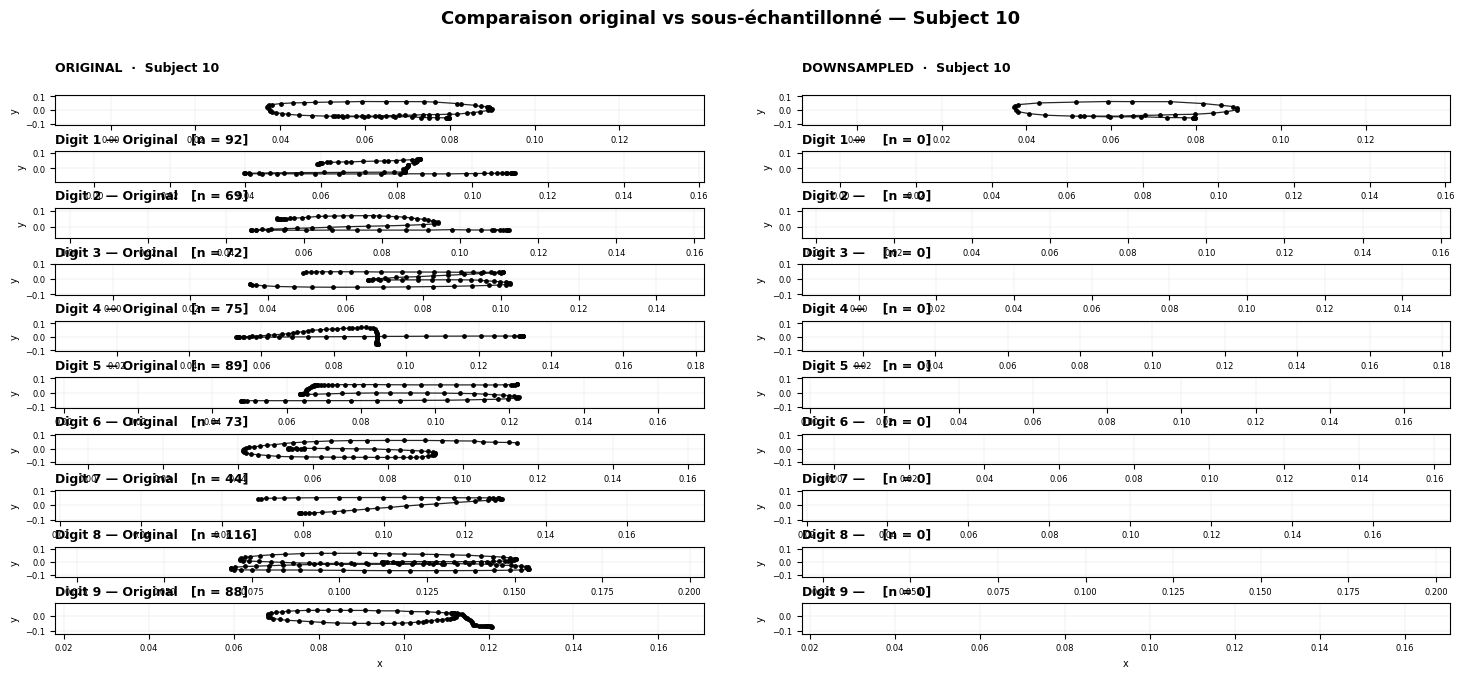

Affichage terminé.


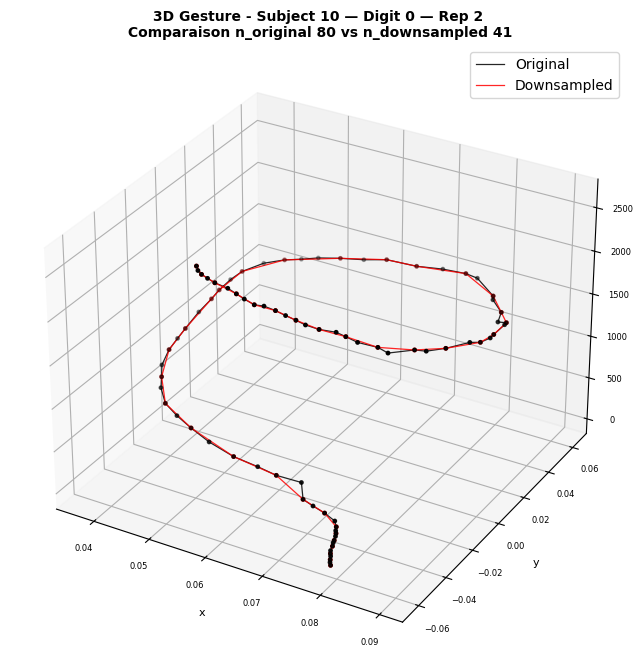

Affichage 3D terminé.


In [6]:
df_domain1 = dataset_domain1.copy() # pour éviter de modifier le dataset original

print("Sous-echantillonnage des données Domain1...")

df_domain1_downsampled = (
    df_domain1.groupby(['subject_id', 'digit', 'repetition']) 
    .apply(downsample_data)
    .reset_index(drop=True)
)

print(generer_statistiques_downsampling(df_domain1, df_domain1_downsampled))

original_count = len(df_domain1) 
downsampled_count = len(df_domain1_downsampled)
reduction = (1-downsampled_count/original_count)*100

print(f"Terminé !")
print(f"Points originaux     : {original_count:,}")
print(f"Points sous-échant.  : {downsampled_count:,}")
print(f"Réduction effective  : {reduction:.1f}%")

# 2. Calcul des gestes (combinaisons uniques sujet/digit/rep)
def count_gestures(df):
    return len(df.groupby(['subject_id', 'digit', 'repetition']))

old_gestures = count_gestures(df_domain1)
new_gestures = count_gestures(df_domain1_downsampled)

print(f"=== BILAN DU PRÉ-TRAITEMENT ===")
print(f"Points (coordonnées) : {original_count:,} -> {downsampled_count:,} ({reduction:.1f}% de réduction)")
print(f"Gestes (séquences)   : {old_gestures} -> {new_gestures} (Conservation: {(new_gestures/old_gestures)*100:.1f}%)")

if old_gestures == new_gestures:
    print(" Succès : Tous les gestes ont été conservés.")
else:
    print(f" Attention : {old_gestures - new_gestures} geste(s) perdu(s).")

# ligne a décommenter pour sauvegarder le dataset traité dans un fichier csv
#df_domain1_downsampled.to_csv(os.path.join(BASE_DIR, "Dataset", "Domain1_aggregated_csv", "Domain1_downsampled_dataset.csv"), index=False)

# prendre un subset 
subset = df_domain1[(df_domain1['subject_id'] == 1) & (df_domain1['digit'] == 0)]

for (subject_id, digit,rep), group in subset.groupby(['subject_id', 'digit', 'repetition']):
   print(f"Subject ID: {subject_id}, Digit: {digit}, Number of rows: {len(group)}")


# code pour afficher les points avant et après le sous-échantillonnage pour un groupe spécifique (par exemple, subject_id=1, digit=0)

plot_xy_grid(df = df_domain1, df_downsampled= df_domain1_downsampled, subject=10)

plot_3d(df= df_domain1, df_downsampled=df_domain1_downsampled, subject=10, digit=0)


In [7]:
print(
    df_domain1_downsampled[df_domain1_downsampled['subject_id'] == 10]
    .groupby(['digit', 'repetition'])
    .size()
)

digit  repetition
0      1             79
       2             41
       3             42
       4             45
       5             45
                     ..
9      6             45
       7             49
       8             55
       9             89
       10            60
Length: 100, dtype: int64


## Domain 4

Sous-echantillonnage des données Domain4...


C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\4030517677.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain4.groupby(['subject_id', 'digit', 'repetition'])


        subject_id        digit   repetition   n_original  n_downsampled  \
count  1003.000000  1003.000000  1003.000000  1003.000000    1003.000000   
mean      5.499501     5.502493     5.516451   139.569292      70.791625   
std       2.872325     2.874755     2.885105    43.690185      21.656073   
min       1.000000     1.000000     1.000000    56.000000      34.000000   
25%       3.000000     3.000000     3.000000   110.000000      56.000000   
50%       6.000000     6.000000     6.000000   131.000000      66.000000   
75%       8.000000     8.000000     8.000000   161.000000      82.000000   
max      10.000000    10.000000    11.000000   314.000000     158.000000   

             ratio  
count  1003.000000  
mean      0.509391  
std       0.038215  
min       0.494845  
25%       0.503876  
50%       0.505882  
75%       0.508333  
max       1.000000  
Terminé !
Points originaux     : 139,988
Points sous-échant.  : 71,004
Réduction effective  : 49.3%
=== BILAN DU PRÉ-TRAITEMEN

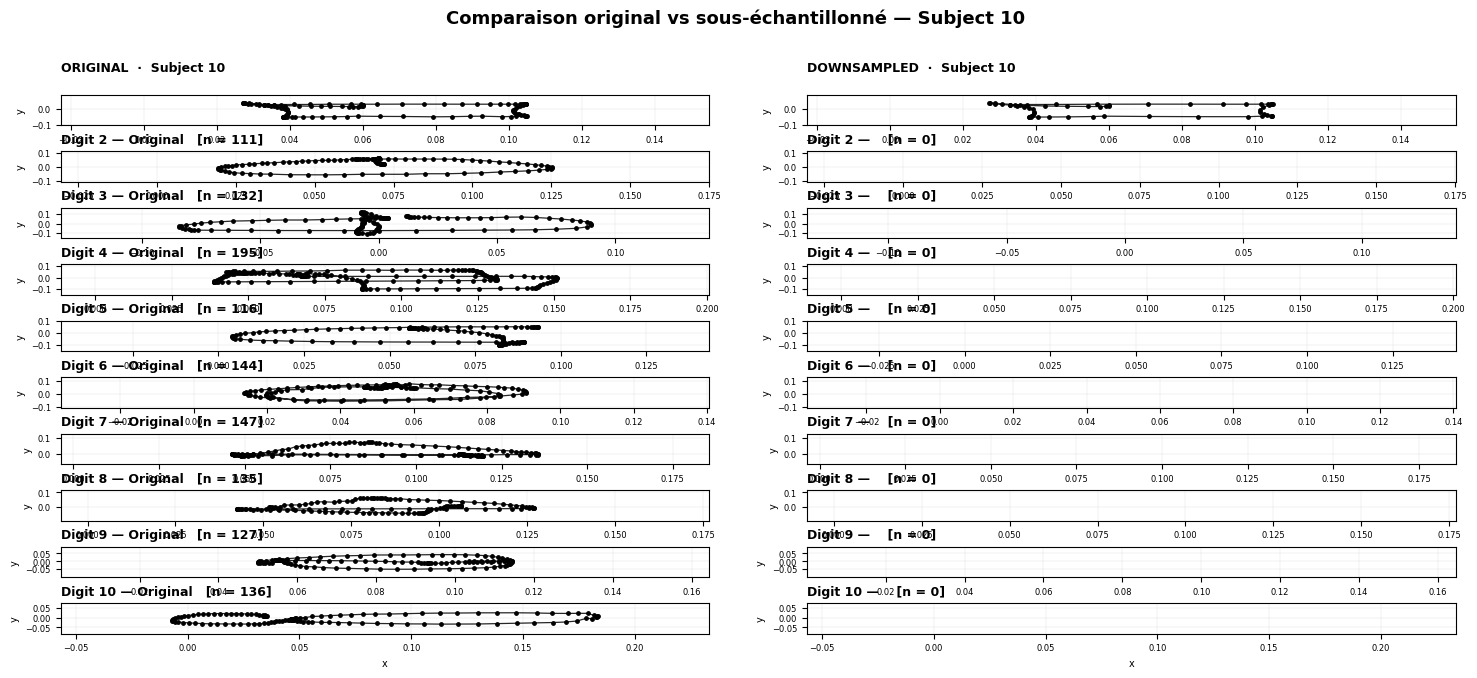

Affichage terminé.


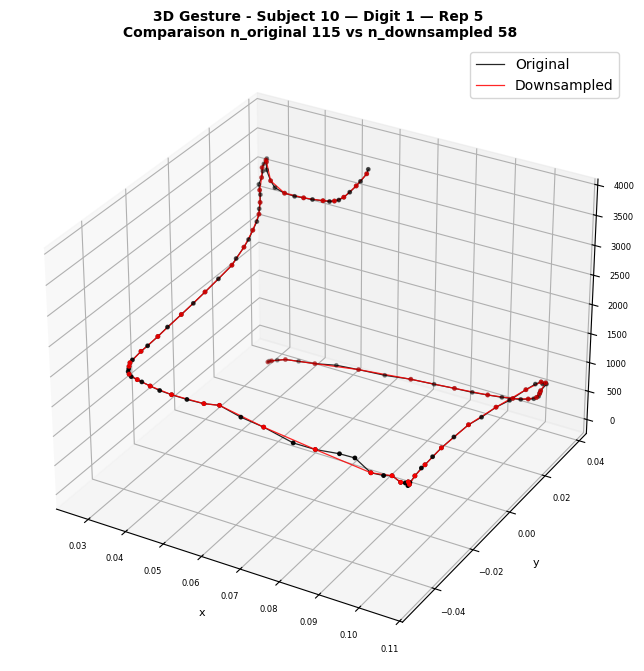

Affichage 3D terminé.


In [6]:
df_domain4 = dataset_domain4.copy() # pour éviter de modifier le dataset original


print("Sous-echantillonnage des données Domain4...")

df_domain4_downsampled = (
    df_domain4.groupby(['subject_id', 'digit', 'repetition']) 
    .apply(downsample_data)
    .reset_index(drop=True)
)

print(generer_statistiques_downsampling(df_domain4, df_domain4_downsampled))

original_count = len(df_domain4) 
downsampled_count = len(df_domain4_downsampled)
reduction = (1 - downsampled_count / original_count) * 100

print("Terminé !")
print(f"Points originaux     : {original_count:,}")
print(f"Points sous-échant.  : {downsampled_count:,}")
print(f"Réduction effective  : {reduction:.1f}%")

old_gestures = count_gestures(df_domain4)
new_gestures = count_gestures(df_domain4_downsampled)

print("=== BILAN DU PRÉ-TRAITEMENT DOMAIN 4 ===")
print(f"Points (coordonnées) : {original_count:,} -> {downsampled_count:,} ({reduction:.1f}% de réduction)")
print(f"Gestes (séquences)   : {old_gestures} -> {new_gestures} (Conservation: {(new_gestures / old_gestures) * 100:.1f}%)")

if old_gestures == new_gestures:
    print("Succès : Tous les gestes ont été conservés.")
else:
    print(f"Attention : {old_gestures - new_gestures} geste(s) perdu(s).")

# Vérification sur un digit existant
first_digit_domain4 = sorted(df_domain4['digit'].unique())[0]

subset = df_domain4[
    (df_domain4['subject_id'] == 1) &
    (df_domain4['digit'] == first_digit_domain4)
]

for (subject_id, digit, rep), group in subset.groupby(['subject_id', 'digit', 'repetition']):
   print(f"Subject ID: {subject_id}, Digit: {digit}, Repetition: {rep}, Number of rows: {len(group)}")

# Visualisations
plot_xy_grid(df=df_domain4, df_downsampled=df_domain4_downsampled, subject=10)

plot_3d(df=df_domain4, df_downsampled=df_domain4_downsampled, subject=10, digit=first_digit_domain4)

# Prepocessing 

In [7]:
print("Standardisation individuelle des gestes en cours...")

# 1. La standardisation PAR GESTE permettant de centrer et réduire chaque trajectoire 3D

def standardize_group(group):
    coords = group[['x', 'y', 'z']].values 

    gravity_center = np.mean(coords, axis=0)
    std = np.std(coords, axis=0)
    std[std == 0] = 1 # Sécurité pour éviter la division par zéro
    
    coords_std = (coords - gravity_center) / std
    
    # On ajoute directement les colonnes au groupe
    group['x_std'] = coords_std[:, 0]
    group['y_std'] = coords_std[:, 1]
    group['z_std'] = coords_std[:, 2]

    return group

# On l'applique sur chaque geste du df_downsampled et df initial

#Domain 1
df_domain1_downsampled = df_domain1_downsampled.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group) 

df_domain1 = df_domain1.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group) 

#Domain 4
df_domain4_downsampled = df_domain4_downsampled.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group)  

df_domain4 = df_domain4.groupby(
    ['subject_id', 'digit', 'repetition'], group_keys=False
    ).apply(standardize_group)

# 2. Extraction des points Domain 1
points_3d_downsampled = df_domain1_downsampled[['x_std', 'y_std', 'z_std']].values # on prend les colonnes standardisées pour faire du clustering
points_3d = df_domain1[['x_std', 'y_std', 'z_std']].values

# 2.1 Extraction des points Domain 4
#points_3d_downsampled_domain4 = df_domain4_downsampled[['x_std', 'y_std', 'z_std']].values # on prend les colonnes standardisées pour faire du clustering
#points_3d_domain4 = df_domain4[['x_std', 'y_std', 'z_std']].values

print(f"Prêt ! {points_3d_downsampled.shape[0]} points 3D downsampled vont être analysés pour le domaine 1.")
print(f"Prêt ! {points_3d.shape[0]} points 3D vont être analysés pour le domaine 1.")
#print(f"Prêt ! {points_3d_downsampled_domain4.shape[0]} points 3D downsampled vont être analysés pour le domaine 4.")
#print(f"Prêt ! {points_3d_domain4.shape[0]} points 3D vont être analysés pour le domaine 4.")

# ============================================================
# Split Dataset
# ============================================================

# Features: les coordonnées 3D standardisées (x_std, y_std, z_std)
# Labels: la colonne 'digit' qui représente le geste

def split_dataset(df):
    X = df[['x_std', 'y_std', 'z_std']].values  # Features: points 3D standardisés
    y = df['digit'].values

    return X,y

# Split pour Domain 1
X_domain1,y_domain1 = split_dataset(df_domain1)
X_domain1_downsampled,y_domain1_downsampled = split_dataset(df_domain1_downsampled)

# Split pour Domain 4
X_domain4,y_domain4 = split_dataset(df_domain4)
X_domain4_downsampled,y_domain4_downsampled = split_dataset(df_domain4_downsampled)


Standardisation individuelle des gestes en cours...


C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\1394577011.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1_downsampled = df_domain1_downsampled.groupby(
C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\1394577011.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain1 = df_domain1.groupby(
C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\1394577011.py:33: FutureWarning: DataFrameGroupBy

Prêt ! 49282 points 3D downsampled vont être analysés pour le domaine 1.
Prêt ! 85095 points 3D vont être analysés pour le domaine 1.


C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\1394577011.py:37: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_domain4 = df_domain4.groupby(


# Edit-Distance

## Clustering - Analyse nombre de cluster par la Méthode du coude

Elbow - Domain 1 full dataset
K-Means : Test des k de 2 à 30 ...


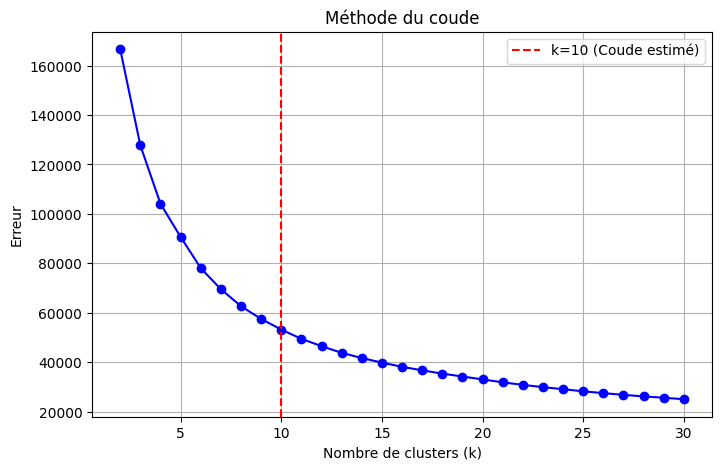

Elbow - Domain 1 downsampled
K-Means : Test des k de 2 à 30 ...


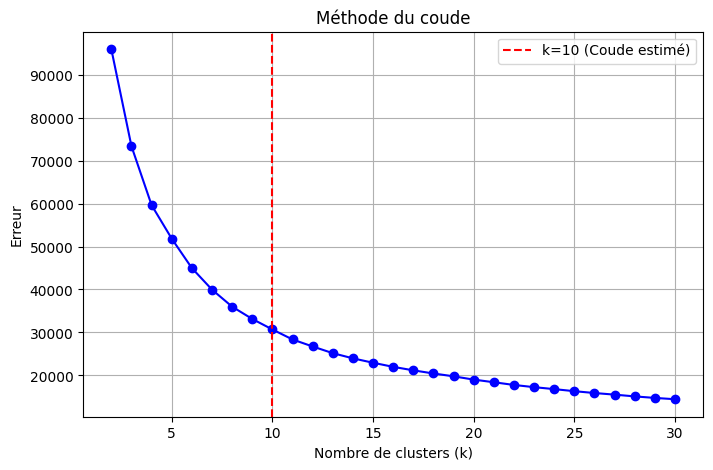

In [7]:

# 3. Méthode du coude
def plot_elbow_method(X, max_k=30): 
    errors = []
    k_values = range(2, max_k + 1)
    
    print(f"K-Means : Test des k de 2 à {max_k} ...")
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X) 
        errors.append(kmeans.inertia_) # inertia_ est la somme des distances au carré entre les points et leur centre de cluster (plus c'est bas, mieux c'est)

    plt.figure(figsize=(8,5))
    plt.plot(k_values, errors, marker='o', color='b')
    
    # On ajoute une ligne pointillée sur k=10 pour le mettre en évidence
    plt.axvline(x=10, color='r', linestyle='--', label='k=10 (Coude estimé)')
    
    plt.title('Méthode du coude')
    plt.xlabel('Nombre de clusters (k)')
    plt.ylabel("Erreur")
    plt.legend()
    plt.grid(True)
    plt.show()

print("Elbow - Domain 1 full dataset")
plot_elbow_method(X_domain1)

print("Elbow - Domain 1 downsampled")
plot_elbow_method(X_domain1_downsampled)


Elbow - Domain 4 full dataset
K-Means : Test des k de 2 à 30 ...


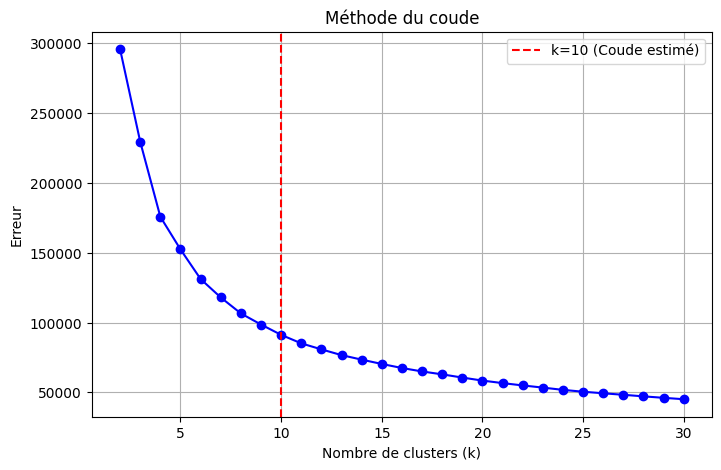

Elbow - Domain 4 downsampled
K-Means : Test des k de 2 à 30 ...


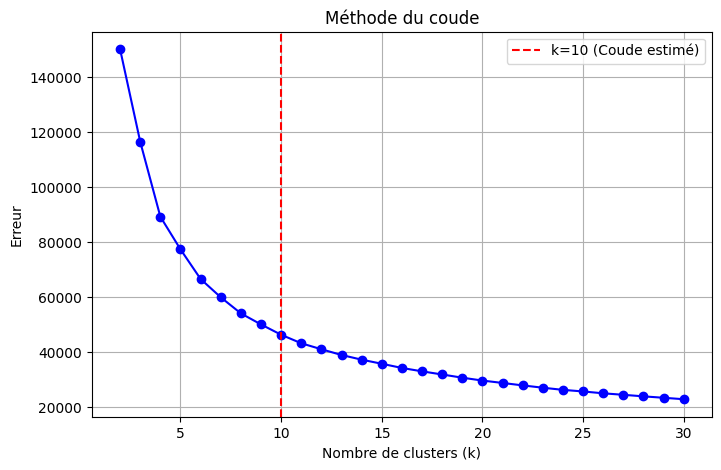

In [8]:

print("Elbow - Domain 4 full dataset")
plot_elbow_method(X_domain4)

print("Elbow - Domain 4 downsampled")
plot_elbow_method(X_domain4_downsampled)

Méthode du coude peu efficace donc on va tester l'hyperparametre k pour visualiser quelle valeur de k prévue entre 10 et 20 inclus par pas de 2 maximise l'accuracy du classifieur complète k-NN sur base de l'edit distance. 

### Traduction des clusters en alphabet

In [8]:
print("Création de l'alphabet et traduction...")

# 1. Entraînement du modèle définitif avec le k=10 (choisi à partir de la méthode du coude)

#valeur voir Test de l'hyperparamètre k pour k-Means



k_optimal_domain1 = 10
k_optimal_domain1_downsampled = 12
k_optimal_domain4 = 20
k_optimal_domain4_downsampled = 12

print(f"Apprentissage des {k_optimal_domain1} lettres de l'alphabet spatial...")

def kMeans_application(X, k_optimal):
    kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
    kmeans_final.fit(X)

    #centroids = kmeans_final.cluster_centers_
    #print(centroids) #print un tableau de forme (n_clusters,3) avec les 2 coordonées (x,y,z) de chaque centroide 
    # a récupérer pour le test

    return kmeans_final

#KMeans pour Domain 1
kmeans_final_domain1 = kMeans_application(X_domain1, k_optimal_domain1) # meilleur accuracy 10
kmeans_final_domain1_downsampled = kMeans_application(X_domain1_downsampled, k_optimal_domain1_downsampled ) # meilleur accuracy 12

#KMeans pour Domain 4
kmeans_final_domain4 = kMeans_application(X_domain4, k_optimal_domain4 ) # meilleur accuracy 20
kmeans_final_domain4_downsampled = kMeans_application(X_domain4_downsampled, k_optimal_domain4_downsampled) # meilleur accuracy 12

# 2. La fonction de traduction (de points 3D vers du Texte)
def traduire_en_lettres(group,kmeans_final):
    # On extrait les points standardisés du geste
    coords = group[['x_std', 'y_std', 'z_std']].values
    
    # Le K-Means attribue chaque point à son cluster le plus proche (de 0 à 12)
    labels = kmeans_final.predict(coords)
    
    # On transforme le numéro en lettre (0 -> A, 1 -> B, ..., 12 -> M)
    # L'astuce : chr(65) donne 'A' en informatique (code ASCII)
    lettres = [chr(65 + label) for label in labels]
    
    # On colle toutes les lettres pour faire un seul mot (ex: "AABBCCC...")
    mot = "".join(lettres)
    
    # On retourne une petite boîte contenant notre mot
    return pd.Series({'mot_traduit': mot})

print("Traduction des gestes en texte ...")

def creer_et_sauvegarder_dictionnaire(df, kmeans_model, is_downsampled=False, domain_name="Domain1"):
    """
    Traduit les gestes en mots, sauvegarde le CSV et affiche un aperçu.
    Le nom du fichier s'adapte automatiquement selon is_downsampled.
    """
   
    # 1. Gestion du nommage (le paramètre magique)
    suffixe = "_downsampled" if is_downsampled else ""
    nom_fichier = f"{domain_name}_dictionnaire_mots{suffixe}.csv"
   
    # 2. Application de la traduction
    # On utilise le df et le modèle KMeans passés en paramètres
    df_mots = df.groupby(['subject_id', 'digit', 'repetition']).apply(
        traduire_en_lettres,
        kmeans_final=kmeans_model
    ).reset_index()
 
    # 3. Préparation de la sauvegarde
    output_dir = os.path.join(BASE_DIR, "Dataset", "Aggregated_csv")
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, nom_fichier)
 
    # 4. Sauvegarde (à décommenter quand tu es prêt)
    # df_mots.to_csv(output_path, index=False)
 
    # 5. Affichage dynamique
    type_donnees = "downsampled" if is_downsampled else "original"
    print(f"Terminé ! Le dictionnaire [{type_donnees}] est sauvegardé ici : {output_path}")
    print(f"\nAperçu des données ({type_donnees}) prêtes pour l'Edit Distance :")
    print(df_mots.head(10))
    print("-" * 50) # Petite ligne de séparation visuelle
   
    return df_mots
 
# ==========================================
# UTILISATION DE LA FONCTION
# ==========================================
 
# 1. Pour les données Originales (is_downsampled = False)
df_domain1_mots = creer_et_sauvegarder_dictionnaire(
    df=df_domain1,
    kmeans_model=kmeans_final_domain1,
    is_downsampled=False
)
 
# 2. Pour les données Downsamplées (is_downsampled = True)
df_domain1_downsampled_mots = creer_et_sauvegarder_dictionnaire(
    df=df_domain1_downsampled,
    kmeans_model=kmeans_final_domain1_downsampled,
    is_downsampled=True
)

# 1. Pour les données Originales (is_downsampled = False)
df_domain4_mots = creer_et_sauvegarder_dictionnaire(
    df=df_domain4,
    kmeans_model=kmeans_final_domain4,
    is_downsampled=False
)
 
# 2. Pour les données Downsamplées (is_downsampled = True)
df_domain4_downsampled_mots = creer_et_sauvegarder_dictionnaire(
    df=df_domain4_downsampled,
    kmeans_model=kmeans_final_domain4_downsampled,
    is_downsampled=True
)


Création de l'alphabet et traduction...
Apprentissage des 10 lettres de l'alphabet spatial...
Traduction des gestes en texte ...


C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\3001510291.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mots = df.groupby(['subject_id', 'digit', 'repetition']).apply(


Terminé ! Le dictionnaire [original] est sauvegardé ici : c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\Dataset\Aggregated_csv\Domain1_dictionnaire_mots.csv

Aperçu des données (original) prêtes pour l'Edit Distance :
   subject_id  digit  repetition  \
0           1      0           1   
1           1      0           2   
2           1      0           3   
3           1      0           4   
4           1      0           5   
5           1      0           6   
6           1      0           7   
7           1      0           8   
8           1      0           9   
9           1      0          10   

                                         mot_traduit  
0  HHHHHHHHHHHHHHHHHHHHHGGGGGGGGGGGGGGGGGGGBBBBBB...  
1  FFFFFFFFFFFEEEEEEEEEEEEEHHHHHHHHGGGGGGGGGGGGGG...  
2  FFFFFFFFFFFFFFFFEEEEEEEEEEEEHHHHHHHHHHHHHHHGGG...  
3  EEEEEEEEEHHHHHHHHHHHHHGGGGGGGGGGGGGGBBBBBBBBBB...  
4  GGGGGGGGGGGGGGGGBBBBBBBBBBBBBBBDDDJJJJJJJJJJJJ... 

C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\3001510291.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mots = df.groupby(['subject_id', 'digit', 'repetition']).apply(


Terminé ! Le dictionnaire [downsampled] est sauvegardé ici : c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\Dataset\Aggregated_csv\Domain1_dictionnaire_mots_downsampled.csv

Aperçu des données (downsampled) prêtes pour l'Edit Distance :
   subject_id  digit  repetition  \
0           1      0           1   
1           1      0           2   
2           1      0           3   
3           1      0           4   
4           1      0           5   
5           1      0           6   
6           1      0           7   
7           1      0           8   
8           1      0           9   
9           1      0          10   

                                         mot_traduit  
0  CCCCBBBBBBBBBKKKKKKKKKKIIIIIIIFFFFFAAAAAAAAJJJ...  
1  JJJJJHHHHHHHBBBBBBBKKKKKKKKKKKKIIIIIIIFFFFAAAA...  
2  JJJJJJJJHHHHHHCBBBBBBBBBBBKKKKKKKKKKKKKKKKIIII...  
3  CCCCCCCBBBBBBKKKKKKKIIIGGIFFAAAAAAJJJJJHHHHHHC...  
4  KKKKKKKKKIIIIIIIFFAAAAAAAJJJJJJJ

C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\3001510291.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mots = df.groupby(['subject_id', 'digit', 'repetition']).apply(


Terminé ! Le dictionnaire [original] est sauvegardé ici : c:\Users\lechef\OneDrive - Haute Ecole Louvain en Hainaut\Bureau\Projet_IA\Gesture-Recognition-Project\Dataset\Aggregated_csv\Domain1_dictionnaire_mots.csv

Aperçu des données (original) prêtes pour l'Edit Distance :
   subject_id  digit  repetition  \
0           1      1           1   
1           1      1           2   
2           1      1           3   
3           1      1           4   
4           1      1           5   
5           1      1           6   
6           1      1           7   
7           1      1           8   
8           1      1           9   
9           1      1          10   

                                         mot_traduit  
0  NNNNNNNNNNNNNNAAAJJJJFFFFFFFFFFFFFFFFFHHHHHHHO...  
1  NNNNNNNNNNNNNNJJJJJFFFFFFFFFFFFFFFFFFHHHHHHOOO...  
2  NNNNNNNNNNNAAAAAFFFFFFFFFFFFFFHHHHHHOOOOOOOOOO...  
3  NNNNNNNNNNNNNNAAAAAAFFFFFFFFFFFFFFHHHHHHOOOOOO...  
4  NNNNNNNNNNNNNNJJJJJJFFFFFFFFFFFFFFFHHHHHHHOOOO... 

C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\3001510291.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_mots = df.groupby(['subject_id', 'digit', 'repetition']).apply(


### Application de l'édit distance

In [9]:
def knn_edit_distance(test_gesture, training_gestures, k= 5):
    distances = []

    for train_gesture in training_gestures:
        dist = edit_distance(test_gesture['mot_traduit'], train_gesture['mot_traduit'])

        max_len = max(len(test_gesture['mot_traduit']),len(train_gesture['mot_traduit']))

        dist = dist/max_len if max_len> 0 else 0

        distances.append((dist, train_gesture['digit']))
    
    # Trier par distance et prendre les k plus proches
    distances.sort(key=lambda x: x[0]) #plus petite au début
    nearest_neighbors = distances[:k]
    
    # Prendre la classe majoritaire parmi les voisins
    classes = [neighbor[1] for neighbor in nearest_neighbors] #extrait la classe (digits) des voisins
    predicted_class = max(set(classes), key=classes.count) #classe majoritaire
    
    return predicted_class

## Test de l'hyperparamètre k pour k-Means

test basé sur 2 répétitions de chaque chiffre par chaque utilisateur (1 répétitions train et 1 pour le test) on récupère les répétitions 5 et 6 (au centre de 1 à 10) pour laisser le temps à l'utilisateur de prendre en main le matériel mais pas trop pour être parfait (représentant un comportement moyen).

Phase d'optimisation tuning hyperparametre : on test la stabilité de l'alphabet symbolique pour un même utilisateur.

Par la suite on va tester la capacité du modèle à reconnaitre les gestes des sujets totalement absents du training (user independent).

Tester avec :
- `df_domain1`
- `df_domain1_downsampled` 
- `df_domain4` 
- `df_domain4_downsampled`

### Test slpit 50/50 train sur répétition 5 et test répétition 6

Train set: (8340, 10)
Test set: (8423, 10)
Subjects train: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Subjects test: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
Digits: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Repetition train : [5] & Repetition test : [6]

Valeurs de k à tester: [10, 12, 14, 16, 18, 20]

--- Test avec k = 10 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.8900 (89.00%)

--- Test avec k = 12 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.9100 (91.00%)

--- Test avec k = 14 ---


...

  Mots train: 100, Mots test: 100
  Accuracy: 0.9300 (93.00%)

--- Test avec k = 18 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.9000 (90.00%)

--- Test avec k = 20 ---


C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_22712\3671167877.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(


  Mots train: 100, Mots test: 100
  Accuracy: 0.8700 (87.00%)

=== RÉSUMÉ DES RÉSULTATS ===
 k  accuracy
10      0.89
12      0.91
14      0.93
16      0.93
18      0.90
20      0.87


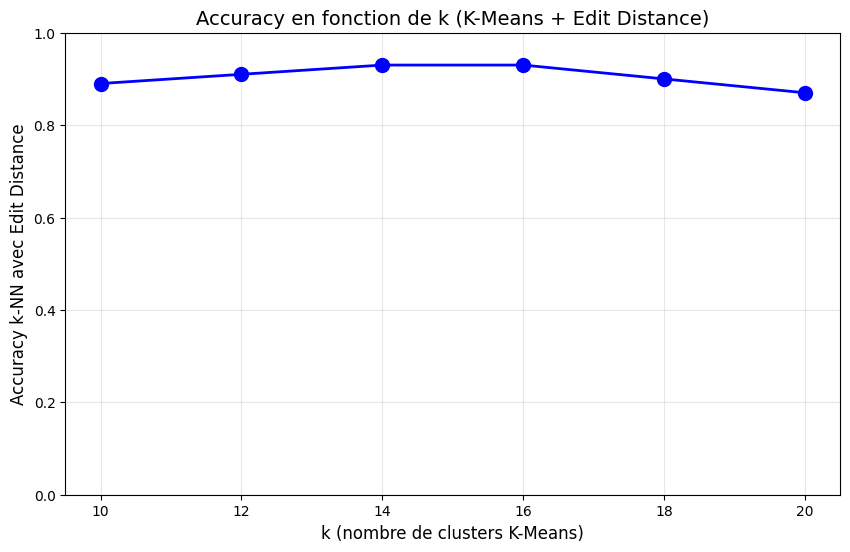


✓ Meilleur k: 14 avec accuracy = 0.9300 (93.00%)


In [ ]:
# ============================================================
# Test hyperparamètre k pour K-Means avec Edit Distance
# ============================================================

# 1. Créer les dataframes de train et test
# a faire varier entre df_domain 1, df_domain1_downsampled etc.
# Train: répétitions 5, Test: répétitions 6

df_train = df_domain1[df_domain1['repetition'] == 5].copy()
df_test = df_domain1[df_domain1['repetition'] == 6].copy()

print(f"Train set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"Subjects train: {sorted(df_train['subject_id'].unique())}")
print(f"Subjects test: {sorted(df_test['subject_id'].unique())}")
print(f"Digits: {sorted(df_test['digit'].unique())}")
print(f"Repetition train : {df_train['repetition'].unique()} & Repetition test : {df_test['repetition'].unique()}")

# 2. Valeurs de k à tester (10 à 20 inclus, pas de 2)
k_values = list(range(10, 21, 2))  # [10, 12, 14, 16, 18, 20]
print(f"\nValeurs de k à tester: {k_values}")

# 3. Boucle de test pour chaque k
results = []

for k in k_values:
    print(f"\n--- Test avec k = {k} ---")
    
    # A. Entraîner K-Means sur les données de train (utilise la fonction existante)
    X_train_k = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = kMeans_application(X_train_k, k)
    
    # B. Traduire les gestes de train en mots (utilise la fonction existante)
    df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    # C. Traduire les gestes de test en mots
    df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    print(f"  Mots train: {len(df_train_mots)}, Mots test: {len(df_test_mots)}")
    
    # D. Appliquer k-NN avec Edit Distance (utilise la fonction existante)
    y_true = []
    y_pred = []
    
    # Convertir en liste de dictionnaires pour utiliser la fonction knn existante
    train_gestures = df_train_mots.to_dict(orient='records')
    
    for idx, test_row in df_test_mots.iterrows():
        test_gesture = test_row.to_dict()
        prediction = knn_edit_distance(test_gesture, train_gestures, k=3)
        
        y_true.append(test_row['digit'])
        y_pred.append(prediction)
    
    # E. Calculer l'accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    results.append({'k': k, 'accuracy': accuracy})

# 4. Résultats
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS ===")
print("="*50)
print(results_df.to_string(index=False))

# 5. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['accuracy'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('k (nombre de clusters K-Means)', fontsize=12)
plt.ylabel('Accuracy k-NN avec Edit Distance', fontsize=12)
plt.title('Accuracy en fonction de k (K-Means + Edit Distance)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

# 6. Meilleur k
best_idx = results_df['accuracy'].idxmax()
best_k = results_df.loc[best_idx, 'k']
best_accuracy = results_df.loc[best_idx, 'accuracy']
print(f"\n✓ Meilleur k: {best_k} avec accuracy = {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

### Split 80/20 for the 5th & 6th repetition of each subject and each digit.

digit
4     2130
6     1518
7     1513
3     1445
10    1377
9     1342
8     1263
1     1243
5     1081
2     1070
Name: count, dtype: int64
Nombre de gestes par chiffre : Counter({'1': 20, '2': 20, '3': 20, '4': 20, '5': 20, '6': 20, '7': 20, '8': 20, '9': 20, '10': 20})
Total gestes: 200
Gestes Train (80%): 160 | Gestes Test (20%): 40

--- Test avec k = 10 ---
  Accuracy: 0.7750 (77.50%)

--- Test avec k = 12 ---
  Accuracy: 0.9000 (90.00%)

--- Test avec k = 14 ---
  Accuracy: 0.8250 (82.50%)

--- Test avec k = 16 ---
  Accuracy: 0.8000 (80.00%)

--- Test avec k = 18 ---
  Accuracy: 0.7750 (77.50%)

--- Test avec k = 20 ---
  Accuracy: 0.8250 (82.50%)

=== RÉSUMÉ DES RÉSULTATS ===
 k  accuracy
10     0.775
12     0.900
14     0.825
16     0.800
18     0.775
20     0.825


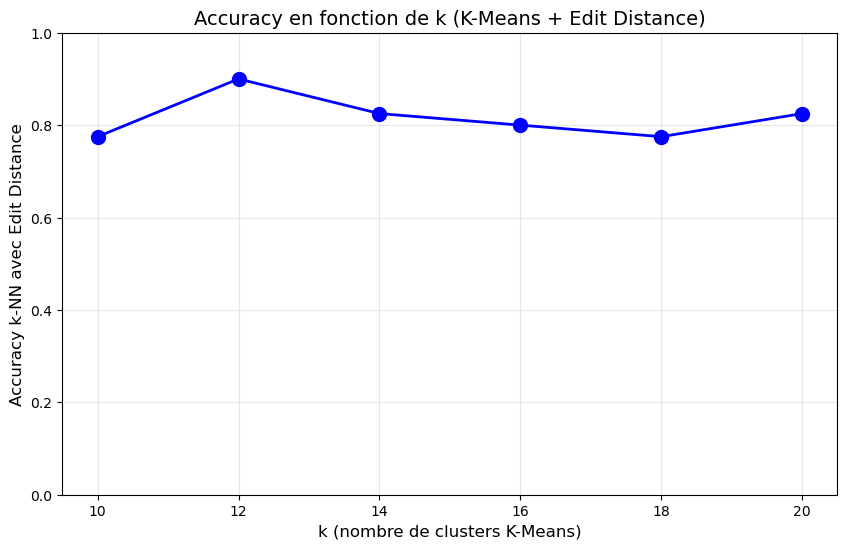


✓ Meilleur k: 12 avec accuracy = 0.9000 (90.00%)


In [18]:
# ============================================================
# Test hyperparamètre k pour K-Means avec Edit Distance
# Split 80/20 basé sur les répétitions 5 et 6
# ============================================================

# 1. Isoler les répétitions 5 et 6
df_subset = df_domain4_downsampled[df_domain4_downsampled['repetition'].isin([5, 6])].copy()

print(df_subset['digit'].value_counts())

# Créer un identifiant unique par geste (sujet + digit + repetition)
# pour ne pas mélanger les points d'un même geste
df_subset['geste_id'] = df_subset['subject_id'].astype(str) + "_" + \
                        df_subset['digit'].astype(str) + "_" + \
                        df_subset['repetition'].astype(str)

unique_gestes = df_subset['geste_id'].unique()

# 2. Split 80/20 des identifiants de gestes
# Stratify permet de garder la même proportion de chiffres (0-9) dans train et test
labels_gestes = [g.split('_')[1] for g in unique_gestes] # Extraction du digit pour stratifier
print("Nombre de gestes par chiffre :", Counter(labels_gestes))
train_ids, test_ids = train_test_split(unique_gestes, test_size=0.20, random_state=42,stratify=labels_gestes)

df_train = df_subset[df_subset['geste_id'].isin(train_ids)].copy()
df_test = df_subset[df_subset['geste_id'].isin(test_ids)].copy()

print(f"Total gestes: {len(unique_gestes)}")
print(f"Gestes Train (80%): {len(train_ids)} | Gestes Test (20%): {len(test_ids)}")

# 3. Valeurs de k à tester
k_values = list(range(10, 21, 2))
results = []

for k in k_values:
    print(f"\n--- Test avec k = {k} ---")
    
    # A. Entraîner K-Means sur les coordonnées 3D du train set
    X_train_k = df_train[['x_std', 'y_std', 'z_std']].values
    kmeans = kMeans_application(X_train_k, k)
    
    # B. Traduire les gestes de train en mots
    df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    # C. Traduire les gestes de test en mots
    df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
        lambda g: traduire_en_lettres(g, kmeans)
    ).reset_index()
    
    # D. Classification k-NN
    y_true, y_pred = [], []
    train_gestures = df_train_mots.to_dict(orient='records')
    
    for _, test_row in df_test_mots.iterrows():
        prediction = knn_edit_distance(test_row.to_dict(), train_gestures, k=3)
        y_true.append(test_row['digit'])
        y_pred.append(prediction)
    
    # E. Calculer l'accuracy
    accuracy = accuracy_score(y_true, y_pred)
    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    results.append({'k': k, 'accuracy': accuracy})

    # 4. Résultats
results_df = pd.DataFrame(results)
print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS ===")
print("="*50)
print(results_df.to_string(index=False))

# 5. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(results_df['k'], results_df['accuracy'], 'bo-', linewidth=2, markersize=10)
plt.xlabel('k (nombre de clusters K-Means)', fontsize=12)
plt.ylabel('Accuracy k-NN avec Edit Distance', fontsize=12)
plt.title('Accuracy en fonction de k (K-Means + Edit Distance)', fontsize=14)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

# 6. Meilleur k
best_idx = results_df['accuracy'].idxmax()
best_k = results_df.loc[best_idx, 'k']
best_accuracy = results_df.loc[best_idx, 'accuracy']
print(f"\n✓ Meilleur k: {best_k} avec accuracy = {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

### Test de l'hyperparamètre k pour KNN

In [ ]:
# ============================================================
# Test hyperparamètre k pour k-NN avec Edit Distance
# ============================================================

# 1. Créer les dataframes de train et test
# À faire varier entre df_domain1, df_domain1_downsampled, df_domain4, df_domain4_downsampled, etc.
# Train: répétitions 5, Test: répétitions 6

df_train = df_domain1[df_domain1['repetition'] == 5].copy()
df_test = df_domain1[df_domain1['repetition'] == 6].copy()

print(f"Train set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"Subjects train: {sorted(df_train['subject_id'].unique())}")
print(f"Subjects test: {sorted(df_test['subject_id'].unique())}")
print(f"Digits: {sorted(df_test['digit'].unique())}")
print(f"Repetition train : {df_train['repetition'].unique()} & Repetition test : {df_test['repetition'].unique()}")

# 2. Fixer le k de K-Means
# Ici, tu mets la valeur trouvée dans le test précédent.
# Exemple : 12 ou 18 selon ton dataset.

k_kmeans_fixed = 18
print(f"\nNombre de clusters K-Means fixé à : {k_kmeans_fixed}")

# 3. Entraîner K-Means une seule fois sur les données de train

X_train_k = df_train[['x_std', 'y_std', 'z_std']].values
kmeans = kMeans_application(X_train_k, k_kmeans_fixed)

# 4. Traduire les gestes de train en mots

df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
    lambda g: traduire_en_lettres(g, kmeans)
).reset_index()

# 5. Traduire les gestes de test en mots

df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
    lambda g: traduire_en_lettres(g, kmeans)
).reset_index()

print(f"\nMots train: {len(df_train_mots)}")
print(f"Mots test: {len(df_test_mots)}")

# 6. Valeurs de k du k-NN à tester
# On teste des valeurs impaires pour éviter les égalités dans le vote majoritaire.

k_nn_values = [1, 3, 5, 7, 9, 11, 15]
print(f"\nValeurs de k-NN à tester: {k_nn_values}")

# 7. Boucle de test pour chaque k du k-NN

results_knn = []

train_gestures = df_train_mots.to_dict(orient='records')

for k_nn in k_nn_values:
    print(f"\n--- Test avec k-NN = {k_nn} ---")

    y_true = []
    y_pred = []

    for idx, test_row in df_test_mots.iterrows():
        test_gesture = test_row.to_dict()

        prediction = knn_edit_distance(
            test_gesture,
            train_gestures,
            k=k_nn
        )

        y_true.append(test_row['digit'])
        y_pred.append(prediction)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    results_knn.append({
        'k_NN': k_nn,
        'accuracy': accuracy
    })

# 8. Résultats

results_knn_df = pd.DataFrame(results_knn)

print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS k-NN ===")
print("="*50)
print(results_knn_df.to_string(index=False))

# 9. Visualisation

plt.figure(figsize=(10, 6))
plt.plot(
    results_knn_df['k_NN'],
    results_knn_df['accuracy'],
    'bo-',
    linewidth=2,
    markersize=10
)

plt.xlabel('k du k-NN (nombre de voisins)', fontsize=12)
plt.ylabel('Accuracy avec Edit Distance', fontsize=12)
plt.title(f'Optimisation du k-NN - K-Means fixé à k={k_kmeans_fixed}', fontsize=14)
plt.xticks(k_nn_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

# 10. Meilleur k-NN

best_idx = results_knn_df['accuracy'].idxmax()
best_k_nn = results_knn_df.loc[best_idx, 'k_NN']
best_accuracy_knn = results_knn_df.loc[best_idx, 'accuracy']

print(f"\n✓ Meilleur k-NN: {best_k_nn} avec accuracy = {best_accuracy_knn:.4f} ({best_accuracy_knn*100:.2f}%)")

digit
8    2193
1    1799
5    1784
4    1760
0    1750
3    1690
9    1644
6    1605
2    1511
7    1027
Name: count, dtype: int64
Nombre de gestes par chiffre : Counter({'0': 20, '1': 20, '2': 20, '3': 20, '4': 20, '5': 20, '6': 20, '7': 20, '8': 20, '9': 20})
Total gestes: 200
Gestes Train (80%): 160 | Gestes Test (20%): 40
Train set: (13047, 11)
Test set: (3716, 11)

K-Means fixé à k = 10


C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\1950911852.py:54: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
C:\Users\lechef\AppData\Local\Temp\ipykernel_18428\1950911852.py:59: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(



Mots train: 160
Mots test: 40

Valeurs de k-NN à tester: [3, 5, 7, 9, 11, 15]

--- Test avec k-NN = 3 ---
  Accuracy: 0.9250 (92.50%)

--- Test avec k-NN = 5 ---
  Accuracy: 0.8500 (85.00%)

--- Test avec k-NN = 7 ---
  Accuracy: 0.8250 (82.50%)

--- Test avec k-NN = 9 ---
  Accuracy: 0.7750 (77.50%)

--- Test avec k-NN = 11 ---
  Accuracy: 0.7500 (75.00%)

--- Test avec k-NN = 15 ---
  Accuracy: 0.7750 (77.50%)

=== RÉSUMÉ DES RÉSULTATS k-NN ===
 k_NN  accuracy
    3     0.925
    5     0.850
    7     0.825
    9     0.775
   11     0.750
   15     0.775


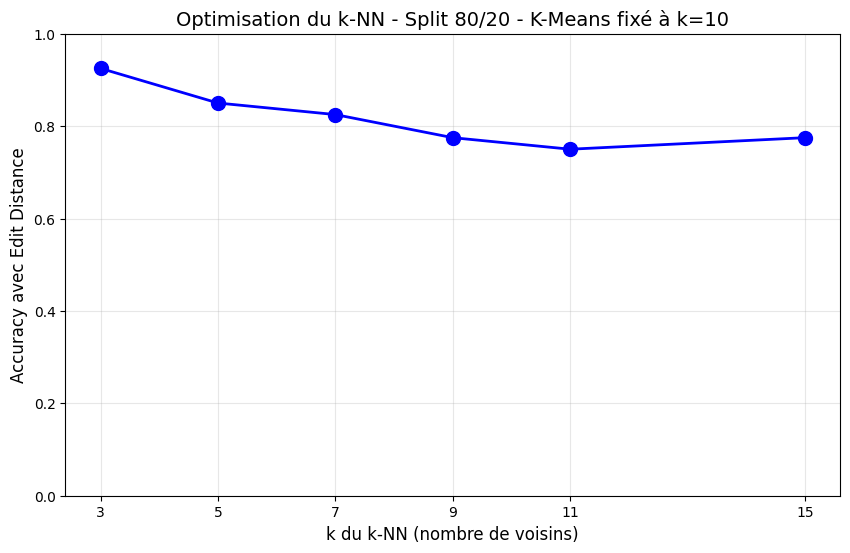


✓ Meilleur k-NN: 3 avec accuracy = 0.9250 (92.50%)


In [10]:
# ============================================================
# Test hyperparamètre k pour k-NN avec Edit Distance
# Split 80/20 basé sur les répétitions 5 et 6
# K-Means fixé
# ============================================================

# 1. Isoler les répétitions 5 et 6
df_subset = df_domain1[df_domain1['repetition'].isin([5, 6])].copy()

print(df_subset['digit'].value_counts())

# Créer un identifiant unique par geste (sujet + digit + repetition)
# pour ne pas mélanger les points d'un même geste
df_subset['geste_id'] = df_subset['subject_id'].astype(str) + "_" + \
                        df_subset['digit'].astype(str) + "_" + \
                        df_subset['repetition'].astype(str)

unique_gestes = df_subset['geste_id'].unique()

# 2. Split 80/20 des identifiants de gestes
# Stratify permet de garder la même proportion de chiffres (0-9) dans train et test
labels_gestes = [g.split('_')[1] for g in unique_gestes]
print("Nombre de gestes par chiffre :", Counter(labels_gestes))

train_ids, test_ids = train_test_split(
    unique_gestes,
    test_size=0.20,
    random_state=42,
    stratify=labels_gestes
)

df_train = df_subset[df_subset['geste_id'].isin(train_ids)].copy()
df_test = df_subset[df_subset['geste_id'].isin(test_ids)].copy()

print(f"Total gestes: {len(unique_gestes)}")
print(f"Gestes Train (80%): {len(train_ids)} | Gestes Test (20%): {len(test_ids)}")
print(f"Train set: {df_train.shape}")
print(f"Test set: {df_test.shape}")

# 3. Fixer le k de K-Means
# Mets ici la meilleure valeur trouvée dans ton test K-Means.
# Exemple dataset 4 : 12 pour downsampled, 20 pour full dataset selon vos résultats.
# Exemple dataset 1 : 10 pour full dataset, 12 pour downsampled selon vos résultats.

k_kmeans_fixed = 10

print(f"\nK-Means fixé à k = {k_kmeans_fixed}")

# 4. Entraîner K-Means une seule fois sur les coordonnées 3D du train set
X_train_k = df_train[['x_std', 'y_std', 'z_std']].values
kmeans = kMeans_application(X_train_k, k_kmeans_fixed)

# 5. Traduire les gestes de train en mots
df_train_mots = df_train.groupby(['subject_id', 'digit', 'repetition']).apply(
    lambda g: traduire_en_lettres(g, kmeans)
).reset_index()

# 6. Traduire les gestes de test en mots
df_test_mots = df_test.groupby(['subject_id', 'digit', 'repetition']).apply(
    lambda g: traduire_en_lettres(g, kmeans)
).reset_index()

print(f"\nMots train: {len(df_train_mots)}")
print(f"Mots test: {len(df_test_mots)}")

# 7. Valeurs de k du k-NN à tester
# On utilise des valeurs impaires pour limiter les égalités dans le vote majoritaire
k_nn_values = [3, 5, 7, 9, 11, 15]

print(f"\nValeurs de k-NN à tester: {k_nn_values}")

# 8. Boucle de test pour chaque k du k-NN
results_knn = []

train_gestures = df_train_mots.to_dict(orient='records')

for k_nn in k_nn_values:
    print(f"\n--- Test avec k-NN = {k_nn} ---")

    y_true = []
    y_pred = []

    for _, test_row in df_test_mots.iterrows():
        prediction = knn_edit_distance(
            test_row.to_dict(),
            train_gestures,
            k=k_nn
        )

        y_true.append(test_row['digit'])
        y_pred.append(prediction)

    accuracy = accuracy_score(y_true, y_pred)

    print(f"  Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

    results_knn.append({
        'k_NN': k_nn,
        'accuracy': accuracy
    })

# 9. Résultats
results_knn_df = pd.DataFrame(results_knn)

print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS k-NN ===")
print("="*50)
print(results_knn_df.to_string(index=False))

# 10. Visualisation
plt.figure(figsize=(10, 6))
plt.plot(
    results_knn_df['k_NN'],
    results_knn_df['accuracy'],
    'bo-',
    linewidth=2,
    markersize=10
)

plt.xlabel('k du k-NN (nombre de voisins)', fontsize=12)
plt.ylabel('Accuracy avec Edit Distance', fontsize=12)
plt.title(f'Optimisation du k-NN - Split 80/20 - K-Means fixé à k={k_kmeans_fixed}', fontsize=14)
plt.xticks(k_nn_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1)
plt.show()

# 11. Meilleur k-NN
best_idx = results_knn_df['accuracy'].idxmax()
best_k_nn = results_knn_df.loc[best_idx, 'k_NN']
best_accuracy_knn = results_knn_df.loc[best_idx, 'accuracy']

print(f"\n✓ Meilleur k-NN: {best_k_nn} avec accuracy = {best_accuracy_knn:.4f} ({best_accuracy_knn*100:.2f}%)")

## Cross validation (User Independant)


A tester sur les données 
- `df_domain1_mots.to_dict(orient='records)` 
- `df_domain1_downsampled_mots.to_dict(orient='records)`
- `df_domain4_mots.to_dict(orient='records)` 
- `df_domain4_downsampled_mots.to_dict(orient='records)`

In [20]:
def split_user(data):
    users = {}

    for gesture in data:
        user_id = gesture['subject_id']

        if user_id not in users:
            users[user_id] = []

        users[user_id].append(gesture)
        
    return users

gestures_user = split_user(df_domain1_mots.to_dict(orient='records'))

for user_id, gestures in gestures_user.items():
    print(f"User {user_id} has {len(gestures)} gestures.")

User 1 has 100 gestures.
User 2 has 100 gestures.
User 3 has 100 gestures.
User 4 has 100 gestures.
User 5 has 100 gestures.
User 6 has 100 gestures.
User 7 has 100 gestures.
User 8 has 100 gestures.
User 9 has 100 gestures.
User 10 has 100 gestures.


In [ ]:
def cross_validation_user_independent(data, knn_func, k=3, plot_confusion=True, title="Matrice de confusion globale (Leave-One-User-Out)"):
    
    users = split_user(data)
    
    accuracies = []
    all_y_true = []
    all_y_pred = []
    
    for test_user in sorted(users.keys()):
        print(f"Testing on user {test_user}...")

        test_gestures = users[test_user]
        training_gestures = []

        for train_user in users:
            if train_user != test_user:
                training_gestures.extend(users[train_user]) 
        
        y_true = [gesture['digit'] for gesture in test_gestures]
        y_pred = [knn_func(gesture, training_gestures, k=k) for gesture in test_gestures]

        accur = accuracy_score(y_true, y_pred)

        print(f"Accuracy for user {test_user}: {accur:.2f}")

        accuracies.append(accur)
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
    
    overall_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"\nMoyenne des Accuracy: {overall_accuracy:.2f}")
    print(f"Ecart-type des accuracies par utilisateur : {std_accuracy:.2f}")

    if plot_confusion:
        labels = sorted(set(all_y_true))
        cm = confusion_matrix(all_y_true, all_y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(title)
        plt.show()
    
    return overall_accuracy, std_accuracy, accuracies, all_y_true, all_y_pred


accuracy_edit_d1_ui, std_edit_d1_ui, accs_edit_d1_ui, y_true_edit_d1_ui, y_pred_edit_d1_ui = cross_validation_user_independent(
    df_domain1_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 1 - User Independent"
)

In [ ]:
accuracy_edit_d1_ui, std_edit_d1_ui, accs_edit_d1_ui, y_true_edit_d1_ui, y_pred_edit_d1_ui = cross_validation_user_independent(
    df_domain1_downsampled_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 1 downsampled - User Independent"
)

In [ ]:
accuracy_edit_d1_ui, std_edit_d1_ui, accs_edit_d1_ui, y_true_edit_d1_ui, y_pred_edit_d1_ui = cross_validation_user_independent(
    df_domain4_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 4 - User Independent"
)

In [ ]:
accuracy_edit_d1_ui, std_edit_d1_ui, accs_edit_d1_ui, y_true_edit_d1_ui, y_pred_edit_d1_ui = cross_validation_user_independent(
    df_domain4_downsampled_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 4 downsampled - User Independent"
)

## Cross Validation (User Dependent)

In [23]:
def split_by_user_and_class(data):
    split_data = {}
    for gesture in data:
        user_id = gesture['subject_id']
        digit = gesture['digit']
        key = (user_id, digit)
        
        if key not in split_data:
            split_data[key] = []
        split_data[key].append(gesture)
    
    return split_data

In [ ]:
def cross_validation_user_dependent(data, knn_func, k=3, plot_confusion=True, title="Matrice de confusion globale (User-Dependent)"):
    split_data = split_by_user_and_class(data)
    
    accuracies = []
    all_y_true = [] 
    all_y_pred = []

    users_unique = sorted(list(set([cle[0] for cle in split_data.keys()])))
    numbers_unique = sorted(list(set([cle[1] for cle in split_data.keys()])))

    for fold in range(10):
        print(f"Fold {fold + 1}/10...")
        y_true_fold = []
        y_pred_fold = []
        
        for user in users_unique:
            test_gestures = []
            training_gestures = []

            for digit in numbers_unique:
                key = (user, digit)

                if key not in split_data:
                    continue
                
                samples = sorted(split_data[key], key=lambda x: x['repetition'])

                if fold >= len(samples):
                    continue

                test_sample = samples[fold]
                train_samples = [s for i, s in enumerate(samples) if i != fold]

                test_gestures.append(test_sample)
                training_gestures.extend(train_samples)
            
            if not test_gestures:
                continue

            y_true = [gesture['digit'] for gesture in test_gestures]
            y_pred = [knn_func(gesture, training_gestures, k=k) for gesture in test_gestures]

            y_true_fold.extend(y_true)
            y_pred_fold.extend(y_pred)
    
        if y_true_fold:
            accur = accuracy_score(y_true_fold, y_pred_fold)
            print(f"Accuracy for fold {fold + 1}: {accur:.2f}")

            accuracies.append(accur)
            all_y_true.extend(y_true_fold)
            all_y_pred.extend(y_pred_fold)

    overall_accuracy = np.mean(accuracies)
    std_accuracy = np.std(accuracies)

    print(f"\nMoyenne des Accuracy: {overall_accuracy:.2f}")
    print(f"Ecart-type des accuracies par fold : {std_accuracy:.2f}")

    if plot_confusion:
        labels = sorted(set(all_y_true))
        cm = confusion_matrix(all_y_true, all_y_pred, labels=labels)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap=plt.cm.Blues)
        plt.title(title)
        plt.show()
    
    return overall_accuracy, std_accuracy, accuracies, all_y_true, all_y_pred


accuracy_edit_d1_ud, std_edit_d1_ud, accs_edit_d1_ud, y_true_edit_d1_ud, y_pred_edit_d1_ud = cross_validation_user_dependent(
    df_domain1_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 1 - User Dependent"
)

In [ ]:
accuracy_edit_d1_ud, std_edit_d1_ud, accs_edit_d1_ud, y_true_edit_d1_ud, y_pred_edit_d1_ud = cross_validation_user_dependent(
    df_domain1_downsampled_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 1 downsampled - User Dependent"
)

In [ ]:
accuracy_edit_d1_ud, std_edit_d1_ud, accs_edit_d1_ud, y_true_edit_d1_ud, y_pred_edit_d1_ud = cross_validation_user_dependent(
    df_domain4_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 4 - User Dependent"
)

In [ ]:
accuracy_edit_d1_ud, std_edit_d1_ud, accs_edit_d1_ud, y_true_edit_d1_ud, y_pred_edit_d1_ud = cross_validation_user_dependent(
    df_domain4_downsampled_mots.to_dict(orient='records'),
    knn_edit_distance,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - Edit Distance - Domain 4 downsampled - User Dependent"
)

# DTW

In [ ]:
print("Préparation des données pour le DTW...")

def prepare_gestures_for_dtw(df):
    gestures_dtw = []

    for (subject_id, digit, repetition), group in df.groupby(['subject_id', 'digit', 'repetition']):
        group = group.sort_index()

        sequence = group[['x_std', 'y_std', 'z_std']].values.astype(np.float32)

        gestures_dtw.append({
            'subject_id': subject_id,
            'digit': int(digit),
            'repetition': int(repetition),
            'sequence': sequence
        })
    
    return gestures_dtw

gestures_dtw_domain1 = prepare_gestures_for_dtw(df_domain1)
gestures_dtw_domain1_downsampled = prepare_gestures_for_dtw(df_domain1_downsampled)

gestures_dtw_domain4 = prepare_gestures_for_dtw(df_domain4)
gestures_dtw_domain4_downsampled = prepare_gestures_for_dtw(df_domain4_downsampled)

gestures_dtw = gestures_dtw_domain1

print(f"{len(gestures_dtw_domain1)} séquences prêtes pour le DTW (Domain 1).")
print(f"{len(gestures_dtw_domain4)} séquences prêtes pour le DTW (Domain 4).")

print(f"Longueur moyenne Domain 1 : {np.mean([len(g['sequence']) for g in gestures_dtw_domain1]):.1f} points")
print(f"Longueur moyenne Domain 4 : {np.mean([len(g['sequence']) for g in gestures_dtw_domain4]):.1f} points")

In [ ]:
def dtw_multivarie(seq1, seq2):
    """
    Calcule la distance DTW entre deux séquences 3D.
    La distance est calculée indépendamment pour X, Y, et Z, puis additionnée.
    """
    distance_totale = 0
    
    # Boucle sur les 3 dimensions : 0=X, 1=Y, 2=Z
    for dim in range(3):
        # On extrait la courbe de la dimension en cours
        s1 = seq1[:, dim]
        s2 = seq2[:, dim]
        n, m = len(s1), len(s2)
        
        # Initialisation de la matrice des coûts avec l'infini
        dtw_matrix = np.full((n + 1, m + 1), np.inf)
        dtw_matrix[0, 0] = 0
        
        # Remplissage de la matrice (programmation dynamique)
        for i in range(1, n + 1):
            for j in range(1, m + 1):
                # La différence absolue entre les deux points
                cout_local = abs(s1[i - 1] - s2[j - 1])
                # On ajoute le chemin le moins coûteux (Insertion, Suppression, ou Correspondance)
                dtw_matrix[i, j] = cout_local + min(dtw_matrix[i-1, j], 
                                                    dtw_matrix[i, j-1], 
                                                    dtw_matrix[i-1, j-1])
                
        # On ajoute le score final de cette dimension au total
        distance_totale += dtw_matrix[n, m]
        
    return distance_totale/(n+m)


def knn_dtw(test_gesture, train_data, k=3):
    """
    Trouve les k-plus proches voisins en utilisant la distance DTW.
    """
    distances = []
    seq_test = test_gesture['sequence']
    
    for train_gesture in train_data:
        seq_train = train_gesture['sequence']
        
        # Calcul de la distance
        dist = dtw_multivarie(seq_test, seq_train)
        
        # On stocke le couple (distance, chiffre_réel)
        distances.append((dist, train_gesture['digit']))
        
    # Tri du plus proche au plus éloigné
    distances.sort(key=lambda x: x[0])
    
    # On garde les K meilleurs et on fait voter
    voisins_gagnants = [label for distance, label in distances[:k]]
    chiffre_predit = Counter(voisins_gagnants).most_common(1)[0][0]
    
    return chiffre_predit

: 

## Test de l'hyperparamètre k pour KNN DTW


In [ ]:
def get_sorted_neighbors_dtw(test_gesture, train_data):
    """
    Calcule toutes les distances DTW, les trie, et renvoie la liste complète.
    Pas de vote ici !
    """
    distances = []
    seq_test = test_gesture['sequence']
    
    for train_gesture in train_data:
        seq_train = train_gesture['sequence']
        dist = dtw_multivarie(seq_test, seq_train)
        distances.append((dist, train_gesture['digit']))
        
    # Tri du plus proche (petite distance) au plus éloigné
    distances.sort(key=lambda x: x[0])
    
    return distances

In [ ]:
# ============================================================
# Test hyperparamètre k pour k-NN avec DTW
# Split 80/20 basé sur les répétitions 5 et 6
# ============================================================

# 1. Isoler les répétitions 5 et 6
df_subset = df_domain4[df_domain4['repetition'].isin([5, 6])].copy()

print("Distribution des chiffres dans le subset :")
print(df_subset['digit'].value_counts())

# Créer un identifiant unique par geste (sujet + digit + repetition)
df_subset['geste_id'] = df_subset['subject_id'].astype(str) + "_" + \
                        df_subset['digit'].astype(str) + "_" + \
                        df_subset['repetition'].astype(str)

unique_gestes = df_subset['geste_id'].unique()

# 2. Split 80/20 des identifiants de gestes
labels_gestes = [g.split('_')[1] for g in unique_gestes]

train_ids, test_ids = train_test_split(
    unique_gestes,
    test_size=0.20,
    random_state=42,
    stratify=labels_gestes
)

df_train = df_subset[df_subset['geste_id'].isin(train_ids)].copy()
df_test = df_subset[df_subset['geste_id'].isin(test_ids)].copy()

print("\n--- Infos sur le Split ---")
print(f"Total gestes: {len(unique_gestes)}")
print(f"Gestes Train (80%): {len(train_ids)} | Gestes Test (20%): {len(test_ids)}")

# 3. Préparer les données au format attendu par ton DTW
# (Utilise ta fonction 'prepare_gestures_for_dtw')
print("\nPréparation des séquences 3D pour le DTW...")
train_gestures_dtw = prepare_gestures_for_dtw(df_train)
test_gestures_dtw = prepare_gestures_for_dtw(df_test)

print(f"Séquences Train prêtes : {len(train_gestures_dtw)}")
print(f"Séquences Test prêtes  : {len(test_gestures_dtw)}")

# 4. Valeurs de k du k-NN à tester
k_nn_values = [1, 3, 5, 7, 9, 11]
max_k = max(k_nn_values) # Ici, 11

print(f"\nValeurs de k-NN à tester en un seul passage: {k_nn_values}")

# On crée un dictionnaire pour stocker les prédictions de chaque k
predictions_per_k = {k: [] for k in k_nn_values}
y_true = []

total_tests = len(test_gestures_dtw)

# LA BOUCLE MAGIQUE : On boucle d'abord sur les gestes (le gros calcul)
for i, test_gesture in enumerate(test_gestures_dtw):
    print(f"Calcul DTW pour geste test {i+1}/{total_tests}...")
    
    y_true.append(test_gesture['digit'])
    
    # 1. LE GROS CALCUL UNE SEULE FOIS : On récupère tous les voisins triés
    sorted_neighbors = get_sorted_neighbors_dtw(test_gesture, train_gestures_dtw)
    
    # 2. On garde juste les 11 plus proches (ton idée !)
    top_11_neighbors = sorted_neighbors[:max_k]
    
    # 3. LE VOTE INSTANTANÉ : On découpe cette petite liste pour chaque k
    for k in k_nn_values:
        # On prend les k premiers de notre top 11
        voisins_gagnants = [label for distance, label in top_11_neighbors[:k]]
        chiffre_predit = Counter(voisins_gagnants).most_common(1)[0][0]
        
        # On sauvegarde le vote
        predictions_per_k[k].append(chiffre_predit)

print("\nCalculs terminés ! Évaluation des scores...")

# 4. On calcule l'accuracy pour chaque k
results_knn = []
for k in k_nn_values:
    y_pred = predictions_per_k[k]
    accuracy = accuracy_score(y_true, y_pred)
    results_knn.append({
        'k_NN': k,
        'accuracy': accuracy
    })

# 6. Résultats et Visualisation
results_knn_df = pd.DataFrame(results_knn)

print("\n" + "="*50)
print("=== RÉSUMÉ DES RÉSULTATS DTW + k-NN ===")
print("="*50)
print(results_knn_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.plot(
    results_knn_df['k_NN'],
    results_knn_df['accuracy'],
    'ro-', # Rouge pour différencier du test K-Means (bleu)
    linewidth=2,
    markersize=10
)

plt.xlabel('k du k-NN (nombre de voisins)', fontsize=12)
plt.ylabel('Accuracy avec DTW', fontsize=12)
plt.title('Optimisation du k-NN (DTW) - Split 80/20', fontsize=14)
plt.xticks(k_nn_values)
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

# 7. Trouver le meilleur k
best_idx = results_knn_df['accuracy'].idxmax()
best_k_nn = int(results_knn_df.loc[best_idx, 'k_NN'])
best_accuracy_knn = results_knn_df.loc[best_idx, 'accuracy']

print(f"\n✓ Meilleur k-NN pour DTW: {best_k_nn} avec accuracy = {best_accuracy_knn:.4f} ({best_accuracy_knn*100:.2f}%)")

## DTW User Independent

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_independent(
    gestures_dtw_domain1,
    knn_dtw,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 1 - User Independent"
)

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_independent(
    gestures_dtw_domain1_downsampled,
    knn_dtw,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 1 downsampled - User Independent"
)

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_independent(
    gestures_dtw_domain4,
    knn_dtw,
    k=5,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 4 - User Independent"
)

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_independent(
    gestures_dtw_domain4_downsampled,
    knn_dtw,
    k=5,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 4 downsampled - User Independent"
)

## DTW User Dependent

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_dependent(
    gestures_dtw_domain1,
    knn_dtw,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 1 - User Dependent"
)

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_dependent(
    gestures_dtw_domain1_downsampled,
    knn_dtw,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 1 downsampled - User Dependent"
)

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_dependent(
    gestures_dtw_domain4,
    knn_dtw,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 4 - User Dependent"
)

In [ ]:
accuracy_dtw_d1_ud, std_dtw_d1_ud, accs_dtw_d1_ud, y_true_dtw_d1_ud, y_pred_dtw_d1_ud = cross_validation_user_dependent(
    gestures_dtw_domain4_downsampled,
    knn_dtw,
    k=3,
    plot_confusion=True,
    title="Matrice de confusion - DTW - Domain 4 downsampled - User Dependent"
)